# Phase 4 — Transfer Learning

## Purpose
We fine-tune three pretrained models on our lung cancer dataset and compare
their performance against the baseline CNN established in Phase 3.

## Models
| Model | Pretrained on | Parameters |
|---|---|---|
| EfficientNetB0 | ImageNet (1.2M images) | ~5.3M |
| InceptionV3 | ImageNet (1.2M images) | ~23.9M |
| ResNet50 | ImageNet (1.2M images) | ~25.6M |

## Two-stage training strategy
Each model is trained in two stages:

**Stage 1 — Feature extraction (5 epochs)**
The pretrained base is completely frozen. Only the new classification
head is trained. This warms up the head weights without disturbing
the pretrained features.

**Stage 2 — Fine-tuning (up to 25 epochs)**
The last 30 layers of the pretrained base are unfrozen and trained
together with the head at a very low learning rate (1e-5).
This adapts the high-level features to our specific domain (histopathology)
without overwriting the universal low-level features learned on ImageNet.

## Output
- 3 trained models saved to `saved_models/`
- Training curves saved to `results/`
- Validation accuracy for each model (used in Phase 5 comparison)

## Step 1 — Imports

In [5]:
import os
os.add_dll_directory(r"C:\Users\ahmed\anaconda3\envs\lung_cancer\Library\bin")

import sys
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path so we can import from src/
sys.path.append(os.path.abspath(".."))

from src.data_preprocessing  import get_data_generators, IMG_SIZE, BATCH_SIZE
from src.model_efficientnet  import build_efficientnet,  unfreeze_efficientnet
from src.model_inception     import build_inception,     unfreeze_inception
from src.model_resnet50      import build_resnet50,      unfreeze_resnet50

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

import tensorflow as tf

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow : 2.10.0
GPU        : True


## Step 2 — Load Data Generators

Same preprocessing pipeline as Phase 3 — imported directly from
`src/data_preprocessing.py`. No new logic here.

In [6]:
import sys
sys.path.append(os.path.abspath(".."))

from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inc_preprocess
from tensorflow.keras.applications.resnet50     import preprocess_input as res_preprocess

DATA_DIR = r"../data/lung_image_sets"

# Each transfer learning model gets its own generator with the correct
# preprocessing function built in. This replaces the Lambda layer approach.
print("Building EfficientNetB0 generators ...")
train_gen_eff, val_gen_eff, test_gen_eff = get_data_generators(
    data_dir               = DATA_DIR,
    img_size               = IMG_SIZE,
    batch_size             = BATCH_SIZE,
    rescale                = False,
    preprocessing_function = eff_preprocess
)

print("\nBuilding InceptionV3 generators ...")
train_gen_inc, val_gen_inc, test_gen_inc = get_data_generators(
    data_dir               = DATA_DIR,
    img_size               = IMG_SIZE,
    batch_size             = BATCH_SIZE,
    rescale                = False,
    preprocessing_function = inc_preprocess
)

print("\nBuilding ResNet50 generators ...")
train_gen_res, val_gen_res, test_gen_res = get_data_generators(
    data_dir               = DATA_DIR,
    img_size               = IMG_SIZE,
    batch_size             = BATCH_SIZE,
    rescale                = False,
    preprocessing_function = res_preprocess
)

Building EfficientNetB0 generators ...
Found 10500 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
───────────────────────────────────────────────────────
  Data Generators Ready
───────────────────────────────────────────────────────
  Image size             : 224 × 224 px
  Batch size             : 32
  Rescaling              : None
  Preprocessing function : preprocess_input
  Train samples          : 10500
  Val   samples          : 2250
  Test  samples          : 2250
  Classes                : {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}
───────────────────────────────────────────────────────

Building InceptionV3 generators ...
Found 10500 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
──────────────────────────────────────────────────

## Step 3 — Shared Utilities

We define two reusable functions used for all three models:

- `get_callbacks()` — builds fresh callbacks for each training run
- `plot_history()` — plots accuracy and loss curves

We define these once here instead of repeating them three times.

### Why fresh callbacks each time?
Keras callbacks are stateful — they track best values and epoch counts
internally. If we reused the same callback objects across models, the
internal state from Model A's training would carry over into Model B's
training, causing incorrect early stopping decisions.

In [7]:
os.makedirs("../saved_models", exist_ok=True)



os.makedirs("../saved_models", exist_ok=True)


def get_callbacks(model_name):
    """
    Returns a fresh set of training callbacks for a given model.
    Must be called separately for each model to reset internal state.

    ModelCheckpoint is intentionally excluded here. In TF 2.10, all
    file-based checkpoint formats (.keras, .h5, .weights.h5) have
    serialization bugs when combined with ReduceLROnPlateau or partially
    frozen architectures. Instead, we save weights manually after training
    using numpy — which is format-agnostic and completely reliable.

    Args:
        model_name (str): Used for display in callback messages.

    Returns:
        list: [EarlyStopping, ReduceLROnPlateau]
    """
    return [
        EarlyStopping(
            monitor              = "val_accuracy",
            patience             = 5,
            restore_best_weights = True,  # best weights restored into model memory
            verbose              = 1
        ),
        ReduceLROnPlateau(
            monitor  = "val_loss",
            factor   = 0.5,
            patience = 3,
            min_lr   = 1e-7,
            verbose  = 1
        )
    ]


def save_weights_numpy(model, model_name):
    """
    Saves model weights as a numpy .npy file.

    Why numpy instead of Keras save formats:
        TF 2.10 has serialization bugs with all Keras weight formats
        (.keras, .h5, .weights.h5) when ReduceLROnPlateau modifies the
        learning rate or when models have partially frozen architectures.

        model.get_weights() returns a plain list of numpy arrays — no
        JSON serialization, no h5py format matching, no optimizer state.
        This is the most reliable save method available in TF 2.10.

    EarlyStopping with restore_best_weights=True has already restored
    the best weights into model memory before this function is called,
    so we are always saving the best weights, not the final epoch weights.

    Args:
        model      (tf.keras.Model): Trained model with best weights loaded.
        model_name (str)           : Used to name the output .npy file.
    """
    save_path = f"../saved_models/{model_name}_weights.npy"

    # get_weights() returns a list of numpy arrays — one per weight tensor
    weights = model.get_weights()

    # allow_pickle=True is required because the list contains arrays
    # of different shapes — numpy needs pickle to store mixed-shape lists
    np.save(save_path, np.array(weights, dtype=object), allow_pickle=True)

    print(f"  💾 Weights saved → saved_models/{model_name}_weights.npy")
    print(f"  Weight tensors saved : {len(weights)}")


print("✅ Callbacks and save utilities ready.")




def plot_history(history_stage1, history_stage2, model_name):
    """
    Plots combined Stage 1 + Stage 2 training curves for accuracy and loss.

    We concatenate the two history objects so the x-axis shows the full
    training timeline across both stages. A vertical dashed line marks
    where Stage 1 ended and Stage 2 began.

    Args:
        history_stage1 : History object from Stage 1 model.fit()
        history_stage2 : History object from Stage 2 model.fit()
        model_name     : Display name for plot title
    """
    # Concatenate metrics from both stages
    acc      = history_stage1.history["accuracy"]     + history_stage2.history["accuracy"]
    val_acc  = history_stage1.history["val_accuracy"] + history_stage2.history["val_accuracy"]
    loss     = history_stage1.history["loss"]         + history_stage2.history["loss"]
    val_loss = history_stage1.history["val_loss"]     + history_stage2.history["val_loss"]
    epochs   = range(1, len(acc) + 1)

    # The epoch where Stage 2 begins
    stage2_start = len(history_stage1.history["accuracy"]) + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, train_metric, val_metric, title, ylabel in zip(
        axes,
        [acc,  loss],
        [val_acc,  val_loss],
        [f"{model_name} — Accuracy", f"{model_name} — Loss"],
        ["Accuracy", "Loss"]
    ):
        ax.plot(epochs, train_metric, color="#378ADD",
                linewidth=2, label="Training")
        ax.plot(epochs, val_metric,   color="#E8593C",
                linewidth=2, linestyle="--", label="Validation")

        # Mark where fine-tuning begins
        ax.axvline(x=stage2_start, color="#1D9E75",
                   linestyle=":", linewidth=1.5, label="Fine-tuning starts")

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    fname = f"../results/{model_name.lower().replace(' ', '_')}_training_curves.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"💾 Saved → {fname}")


print("✅ Utilities ready.")

✅ Callbacks and save utilities ready.
✅ Utilities ready.


## Model 1 — EfficientNetB0

EfficientNetB0 is the most efficient model in our set — it achieves
strong accuracy with the fewest parameters (~5.3M) by using a compound
scaling method that balances depth, width, and resolution simultaneously.

It is the best choice for constrained hardware (our 4GB GPU) and is
often the first model tried in production medical imaging pipelines.

### EfficientNetB0 — Stage 1: Feature Extraction

The base is fully frozen. We train only the classification head for 5 epochs.
This warms up the randomly-initialized head weights so they produce
reasonable gradients before we unfreeze and fine-tune the base.

Without this warm-up step, the large random gradients from an untrained
head could damage the pretrained base weights in the very first epoch.

In [8]:
# Build the model with frozen base
#  EfficientNetB0 Stage 1
effnet_model = build_efficientnet(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=3)

print("\nEfficientNetB0 — Stage 1 training...")
history_eff_s1 = effnet_model.fit(
    train_gen_eff,
    epochs           = 5,
    steps_per_epoch  = train_gen_eff.n // BATCH_SIZE,
    validation_data  = val_gen_eff,
    validation_steps = val_gen_eff.n  // BATCH_SIZE,
    callbacks        = get_callbacks("efficientnetb0"),
    verbose          = 1
)


  EfficientNetB0 built — Stage 1 (base frozen)
  Trainable weight tensors     : 2
  Non-trainable weight tensors : 312

EfficientNetB0 — Stage 1 training...
Epoch 1/5
328/328 [==============================] - 286s 825ms/step - loss: 0.2716 - accuracy: 0.8998 - val_loss: 0.1320 - val_accuracy: 0.9576 - lr: 0.0010
Epoch 2/5
328/328 [==============================] - 221s 674ms/step - loss: 0.1406 - accuracy: 0.9494 - val_loss: 0.1012 - val_accuracy: 0.9665 - lr: 0.0010
Epoch 3/5
328/328 [==============================] - 222s 676ms/step - loss: 0.1196 - accuracy: 0.9556 - val_loss: 0.0859 - val_accuracy: 0.9723 - lr: 0.0010
Epoch 4/5
328/328 [==============================] - 221s 675ms/step - loss: 0.1095 - accuracy: 0.9614 - val_loss: 0.0825 - val_accuracy: 0.9710 - lr: 0.0010
Epoch 5/5
328/328 [==============================] - 219s 668ms/step - loss: 0.1004 - accuracy: 0.9627 - val_loss: 0.0751 - val_accuracy: 0.9754 - lr: 0.0010


### EfficientNetB0 — Stage 2: Fine-tuning

We now unfreeze the last 30 layers of the EfficientNetB0 base and
continue training at a learning rate of 1e-5 (100× smaller than Stage 1).

The green dashed line in the training curves plot will mark where
Stage 2 begins, making it easy to see the improvement from fine-tuning.

  EfficientNetB0 — Stage 2 (last 30 layers unfrozen)
  Trainable weight tensors : 30

EfficientNetB0 — Stage 2 fine-tuning...
Epoch 1/25
328/328 [==============================] - 217s 633ms/step - loss: 0.0878 - accuracy: 0.9676 - val_loss: 0.0565 - val_accuracy: 0.9799 - lr: 1.0000e-05
Epoch 2/25
328/328 [==============================] - 200s 609ms/step - loss: 0.0763 - accuracy: 0.9705 - val_loss: 0.0509 - val_accuracy: 0.9830 - lr: 1.0000e-05
Epoch 3/25
328/328 [==============================] - 200s 610ms/step - loss: 0.0737 - accuracy: 0.9714 - val_loss: 0.0452 - val_accuracy: 0.9862 - lr: 1.0000e-05
Epoch 4/25
328/328 [==============================] - 202s 616ms/step - loss: 0.0634 - accuracy: 0.9761 - val_loss: 0.0452 - val_accuracy: 0.9835 - lr: 1.0000e-05
Epoch 5/25
328/328 [==============================] - 201s 612ms/step - loss: 0.0590 - accuracy: 0.9779 - val_loss: 0.0357 - val_accuracy: 0.9888 - lr: 1.0000e-05
Epoch 6/25
328/328 [==============================] - 201s 

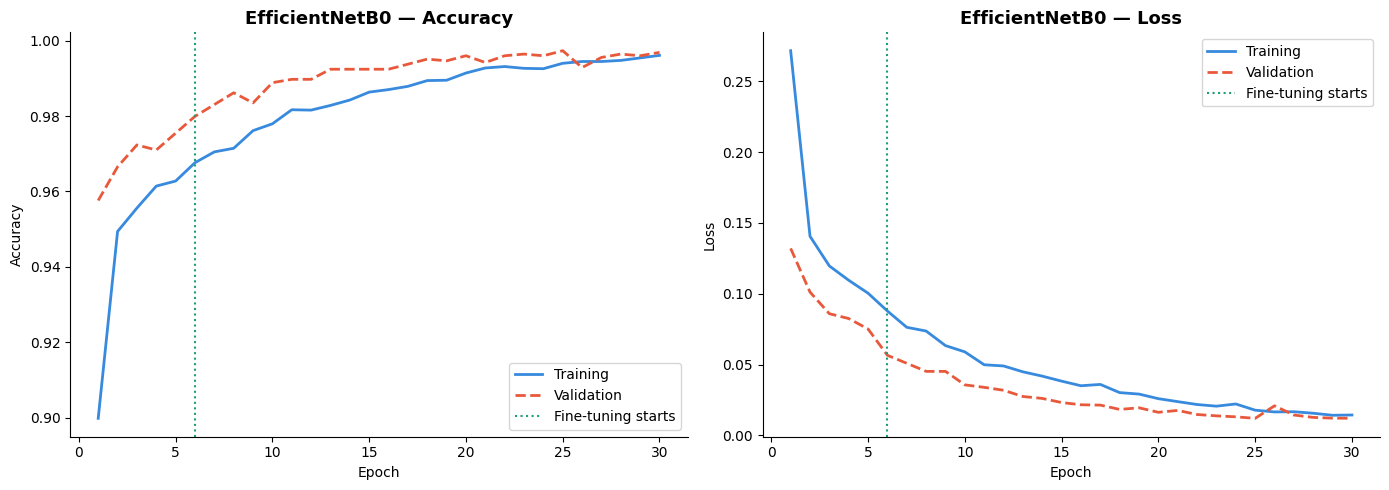

💾 Saved → ../results/efficientnetb0_training_curves.png

EfficientNetB0 — Validation accuracy : 99.73%
EfficientNetB0 — Validation loss     : 0.0120
  💾 Weights saved → saved_models/efficientnetb0_weights.npy
  Weight tensors saved : 314


In [9]:
# EfficientNetB0 — Stage 2
effnet_model = unfreeze_efficientnet(effnet_model, fine_tune_layers=30)

print("\nEfficientNetB0 — Stage 2 fine-tuning...")
history_eff_s2 = effnet_model.fit(
    train_gen_eff,
    epochs           = 25,
    steps_per_epoch  = train_gen_eff.n // BATCH_SIZE,
    validation_data  = val_gen_eff,
    validation_steps = val_gen_eff.n  // BATCH_SIZE,
    callbacks        = get_callbacks("efficientnetb0"),
    verbose          = 1
)

plot_history(history_eff_s1, history_eff_s2, "EfficientNetB0")

loss_eff, acc_eff = effnet_model.evaluate(
    val_gen_eff, steps=val_gen_eff.n // BATCH_SIZE, verbose=0
)
print(f"\nEfficientNetB0 — Validation accuracy : {acc_eff * 100:.2f}%")
print(f"EfficientNetB0 — Validation loss     : {loss_eff:.4f}")

# Save best weights (already restored into memory by EarlyStopping)
save_weights_numpy(effnet_model, "efficientnetb0")

In [10]:
# Verify EfficientNetB0 loads and runs correctly
from src.model_loader import load_model

print("Verifying EfficientNetB0 ...")
loaded = load_model("efficientnetb0")

test_gen_eff.reset()
imgs, _ = next(test_gen_eff)
preds = loaded.predict(imgs[:4], verbose=0)

print(f"  Output shape      : {preds.shape}")        # expected (4, 3)
print(f"  Probabilities sum : {preds[0].sum():.4f}") # expected 1.0000
print(f"  Sample prediction : {preds[0].round(4)}")
print("✅ EfficientNetB0 verified.")
del loaded

Verifying EfficientNetB0 ...
  Building efficientnetb0 architecture ...
  EfficientNetB0 built — Stage 1 (base frozen)
  Trainable weight tensors     : 2
  Non-trainable weight tensors : 312
  Restoring Stage 2 architecture (unfreezing last 30 layers) ...
  EfficientNetB0 — Stage 2 (last 30 layers unfrozen)
  Trainable weight tensors : 30
  Loading weights from efficientnetb0_weights.npy ...
  ✅ efficientnetb0 ready.
  Output shape      : (4, 3)
  Probabilities sum : 1.0000
  Sample prediction : [0. 0. 1.]
✅ EfficientNetB0 verified.


## Model 2 — InceptionV3

InceptionV3 uses "Inception modules" — blocks that apply multiple filter
sizes (1×1, 3×3, 5×5) in parallel on the same input and concatenate
the results. This lets the network capture features at multiple scales
simultaneously without having to choose a single filter size.

It is larger than EfficientNetB0 (~23.9M parameters) but has a strong
track record in medical image classification tasks.

### InceptionV3 — Stage 1: Feature Extraction

In [11]:
#  InceptionV3 Stage 1
inception_model = build_inception(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=3)

print("\nInceptionV3 — Stage 1 training...")
history_inc_s1 = inception_model.fit(
    train_gen_inc,
    epochs           = 5,
    steps_per_epoch  = train_gen_inc.n // BATCH_SIZE,
    validation_data  = val_gen_inc,
    validation_steps = val_gen_inc.n  // BATCH_SIZE,
    callbacks        = get_callbacks("inceptionv3"),
    verbose          = 1
)

  InceptionV3 built — Stage 1 (base frozen)
  Trainable weight tensors     : 2
  Non-trainable weight tensors : 376

InceptionV3 — Stage 1 training...
Epoch 1/5
328/328 [==============================] - 199s 588ms/step - loss: 0.3027 - accuracy: 0.8771 - val_loss: 0.1579 - val_accuracy: 0.9362 - lr: 0.0010
Epoch 2/5
328/328 [==============================] - 188s 574ms/step - loss: 0.1862 - accuracy: 0.9269 - val_loss: 0.1380 - val_accuracy: 0.9433 - lr: 0.0010
Epoch 3/5
328/328 [==============================] - 190s 579ms/step - loss: 0.1808 - accuracy: 0.9299 - val_loss: 0.1185 - val_accuracy: 0.9531 - lr: 0.0010
Epoch 4/5
328/328 [==============================] - 188s 574ms/step - loss: 0.1617 - accuracy: 0.9373 - val_loss: 0.1120 - val_accuracy: 0.9536 - lr: 0.0010
Epoch 5/5
328/328 [==============================] - 188s 574ms/step - loss: 0.1487 - accuracy: 0.9411 - val_loss: 0.1099 - val_accuracy: 0.9531 - lr: 0.0010


### InceptionV3 — Stage 2: Fine-tuning

  InceptionV3 — Stage 2 (last 30 layers unfrozen)
  Trainable weight tensors : 19

InceptionV3 — Stage 2 fine-tuning...
Epoch 1/25
328/328 [==============================] - 199s 588ms/step - loss: 0.1381 - accuracy: 0.9435 - val_loss: 0.0954 - val_accuracy: 0.9607 - lr: 1.0000e-05
Epoch 2/25
328/328 [==============================] - 192s 587ms/step - loss: 0.1206 - accuracy: 0.9532 - val_loss: 0.0807 - val_accuracy: 0.9688 - lr: 1.0000e-05
Epoch 3/25
328/328 [==============================] - 189s 577ms/step - loss: 0.1041 - accuracy: 0.9594 - val_loss: 0.0731 - val_accuracy: 0.9705 - lr: 1.0000e-05
Epoch 4/25
328/328 [==============================] - 191s 583ms/step - loss: 0.0946 - accuracy: 0.9637 - val_loss: 0.0689 - val_accuracy: 0.9754 - lr: 1.0000e-05
Epoch 5/25
328/328 [==============================] - 194s 590ms/step - loss: 0.0903 - accuracy: 0.9660 - val_loss: 0.0595 - val_accuracy: 0.9790 - lr: 1.0000e-05
Epoch 6/25
328/328 [==============================] - 190s 579ms/

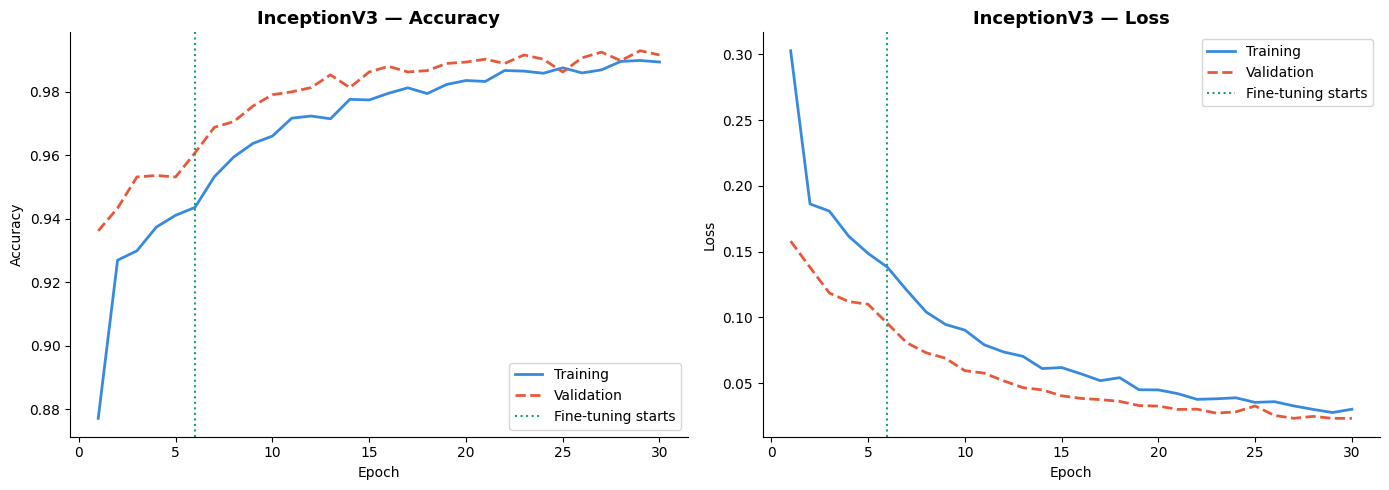

💾 Saved → ../results/inceptionv3_training_curves.png

InceptionV3 — Validation accuracy : 99.15%
InceptionV3 — Validation loss     : 0.0233
  💾 Weights saved → saved_models/inceptionv3_weights.npy
  Weight tensors saved : 378


In [12]:
# InceptionV3 — Stage 2
inception_model = unfreeze_inception(inception_model, fine_tune_layers=30)

print("\nInceptionV3 — Stage 2 fine-tuning...")
history_inc_s2 = inception_model.fit(
    train_gen_inc,
    epochs           = 25,
    steps_per_epoch  = train_gen_inc.n // BATCH_SIZE,
    validation_data  = val_gen_inc,
    validation_steps = val_gen_inc.n  // BATCH_SIZE,
    callbacks        = get_callbacks("inceptionv3"),
    verbose          = 1
)

plot_history(history_inc_s1, history_inc_s2, "InceptionV3")

loss_inc, acc_inc = inception_model.evaluate(
    val_gen_inc, steps=val_gen_inc.n // BATCH_SIZE, verbose=0
)
print(f"\nInceptionV3 — Validation accuracy : {acc_inc * 100:.2f}%")
print(f"InceptionV3 — Validation loss     : {loss_inc:.4f}")

save_weights_numpy(inception_model, "inceptionv3")

In [13]:
# Verify InceptionV3
from src.model_loader import load_model

print("Verifying InceptionV3 ...")
loaded = load_model("inceptionv3")

test_gen_inc.reset()
imgs, _ = next(test_gen_inc)
preds = loaded.predict(imgs[:4], verbose=0)

print(f"  Output shape      : {preds.shape}")
print(f"  Probabilities sum : {preds[0].sum():.4f}")
print(f"  Sample prediction : {preds[0].round(4)}")
print("✅ InceptionV3 verified.")
del loaded

Verifying InceptionV3 ...
  Building inceptionv3 architecture ...
  InceptionV3 built — Stage 1 (base frozen)
  Trainable weight tensors     : 2
  Non-trainable weight tensors : 376
  Restoring Stage 2 architecture (unfreezing last 30 layers) ...
  InceptionV3 — Stage 2 (last 30 layers unfrozen)
  Trainable weight tensors : 19
  Loading weights from inceptionv3_weights.npy ...
  ✅ inceptionv3 ready.
  Output shape      : (4, 3)
  Probabilities sum : 1.0000
  Sample prediction : [0. 0. 1.]
✅ InceptionV3 verified.


## Model 3 — ResNet50

ResNet50 introduced **residual connections** (skip connections) — a technique
where the input to a block is added directly to its output. This solves the
vanishing gradient problem that made very deep networks hard to train before
2015, allowing gradients to flow directly through skip paths during
backpropagation.

"50" refers to the number of layers. It is the heaviest model in our set
(~25.6M parameters) but remains a strong benchmark in computer vision.

### ResNet50 — Stage 1: Feature Extraction

In [14]:
#  ResNet50 Stage 1
resnet_model = build_resnet50(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=3)

print("\nResNet50 — Stage 1 training...")
history_res_s1 = resnet_model.fit(
    train_gen_res,
    epochs           = 5,
    steps_per_epoch  = train_gen_res.n // BATCH_SIZE,
    validation_data  = val_gen_res,
    validation_steps = val_gen_res.n  // BATCH_SIZE,
    callbacks        = get_callbacks("resnet50"),
    verbose          = 1
)

  ResNet50 built — Stage 1 (base frozen)
  Trainable weight tensors     : 2
  Non-trainable weight tensors : 318

ResNet50 — Stage 1 training...
Epoch 1/5
328/328 [==============================] - 284s 851ms/step - loss: 0.2427 - accuracy: 0.9017 - val_loss: 0.1062 - val_accuracy: 0.9589 - lr: 0.0010
Epoch 2/5
328/328 [==============================] - 269s 821ms/step - loss: 0.1330 - accuracy: 0.9466 - val_loss: 0.0891 - val_accuracy: 0.9652 - lr: 0.0010
Epoch 3/5
328/328 [==============================] - 267s 815ms/step - loss: 0.1166 - accuracy: 0.9537 - val_loss: 0.1174 - val_accuracy: 0.9536 - lr: 0.0010
Epoch 4/5
328/328 [==============================] - 268s 818ms/step - loss: 0.1140 - accuracy: 0.9527 - val_loss: 0.0707 - val_accuracy: 0.9692 - lr: 0.0010
Epoch 5/5
328/328 [==============================] - 219s 668ms/step - loss: 0.1003 - accuracy: 0.9598 - val_loss: 0.0723 - val_accuracy: 0.9723 - lr: 0.0010


### ResNet50 — Stage 2: Fine-tuning

  ResNet50 — Stage 2 (last 30 layers unfrozen)
  Trainable weight tensors : 38

ResNet50 — Stage 2 fine-tuning...
Epoch 1/25
328/328 [==============================] - 229s 684ms/step - loss: 0.0770 - accuracy: 0.9693 - val_loss: 0.0491 - val_accuracy: 0.9799 - lr: 1.0000e-05
Epoch 2/25
328/328 [==============================] - 223s 678ms/step - loss: 0.0499 - accuracy: 0.9791 - val_loss: 0.0216 - val_accuracy: 0.9893 - lr: 1.0000e-05
Epoch 3/25
328/328 [==============================] - 222s 677ms/step - loss: 0.0332 - accuracy: 0.9879 - val_loss: 0.0302 - val_accuracy: 0.9879 - lr: 1.0000e-05
Epoch 4/25
328/328 [==============================] - 225s 687ms/step - loss: 0.0243 - accuracy: 0.9907 - val_loss: 0.0063 - val_accuracy: 0.9982 - lr: 1.0000e-05
Epoch 5/25
328/328 [==============================] - 249s 762ms/step - loss: 0.0178 - accuracy: 0.9929 - val_loss: 0.0077 - val_accuracy: 0.9987 - lr: 1.0000e-05
Epoch 6/25
328/328 [==============================] - 240s 731ms/step -

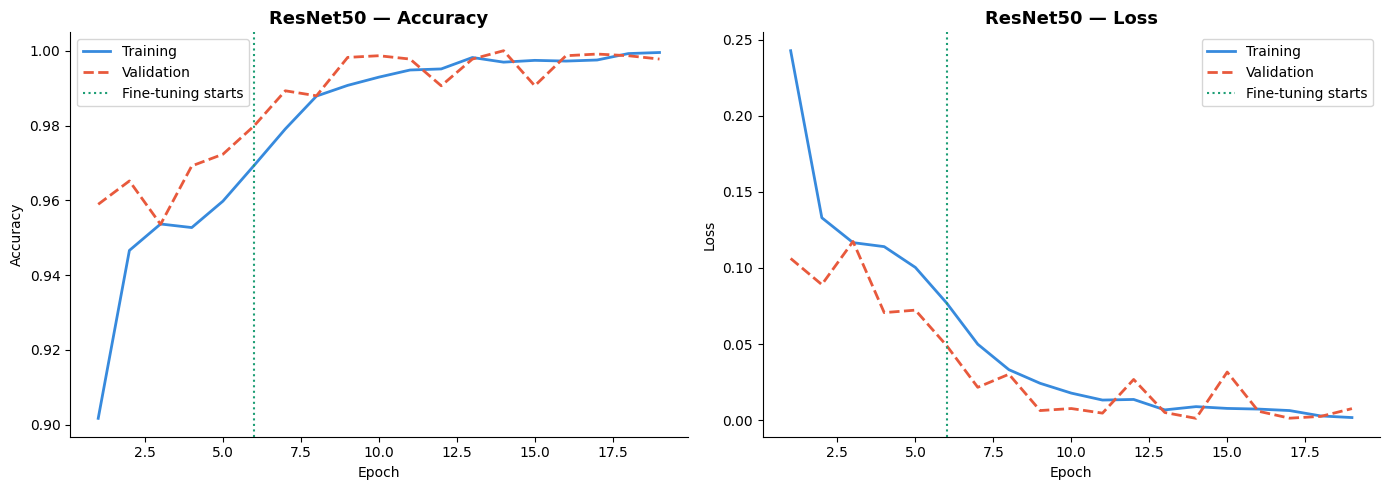

💾 Saved → ../results/resnet50_training_curves.png

ResNet50 — Validation accuracy : 100.00%
ResNet50 — Validation loss     : 0.0012
  💾 Weights saved → saved_models/resnet50_weights.npy
  Weight tensors saved : 320


In [15]:
# ResNet50 — Stage 2
resnet_model = unfreeze_resnet50(resnet_model, fine_tune_layers=30)

print("\nResNet50 — Stage 2 fine-tuning...")
history_res_s2 = resnet_model.fit(
    train_gen_res,
    epochs           = 25,
    steps_per_epoch  = train_gen_res.n // BATCH_SIZE,
    validation_data  = val_gen_res,
    validation_steps = val_gen_res.n  // BATCH_SIZE,
    callbacks        = get_callbacks("resnet50"),
    verbose          = 1
)

plot_history(history_res_s1, history_res_s2, "ResNet50")

loss_res, acc_res = resnet_model.evaluate(
    val_gen_res, steps=val_gen_res.n // BATCH_SIZE, verbose=0
)
print(f"\nResNet50 — Validation accuracy : {acc_res * 100:.2f}%")
print(f"ResNet50 — Validation loss     : {loss_res:.4f}")

save_weights_numpy(resnet_model, "resnet50")

In [16]:
# Verify ResNet50
from src.model_loader import load_model

print("Verifying ResNet50 ...")
loaded = load_model("resnet50")

test_gen_res.reset()
imgs, _ = next(test_gen_res)
preds = loaded.predict(imgs[:4], verbose=0)

print(f"  Output shape      : {preds.shape}")
print(f"  Probabilities sum : {preds[0].sum():.4f}")
print(f"  Sample prediction : {preds[0].round(4)}")
print("✅ ResNet50 verified.")
del loaded

Verifying ResNet50 ...
  Building resnet50 architecture ...
  ResNet50 built — Stage 1 (base frozen)
  Trainable weight tensors     : 2
  Non-trainable weight tensors : 318
  Restoring Stage 2 architecture (unfreezing last 30 layers) ...
  ResNet50 — Stage 2 (last 30 layers unfrozen)
  Trainable weight tensors : 38
  Loading weights from resnet50_weights.npy ...
  ✅ resnet50 ready.
  Output shape      : (4, 3)
  Probabilities sum : 1.0000
  Sample prediction : [0. 0. 1.]
✅ ResNet50 verified.


## Phase 4 Summary — All Models Compared

A quick side-by-side comparison of all four models on validation accuracy.
The full detailed evaluation (confusion matrix, F1, ROC curve) happens
in Phase 5 using the held-out test set.

────────────────────────────────────────────────────
  Phase 4 Summary — Validation Accuracy
────────────────────────────────────────────────────
  Baseline CNN        : 97.72%  ← baseline
  EfficientNetB0      : 99.73%  (+2.01% vs baseline)
  InceptionV3         : 99.15%  (+1.43% vs baseline)
  ResNet50            : 100.00%  (+2.28% vs baseline)
────────────────────────────────────────────────────


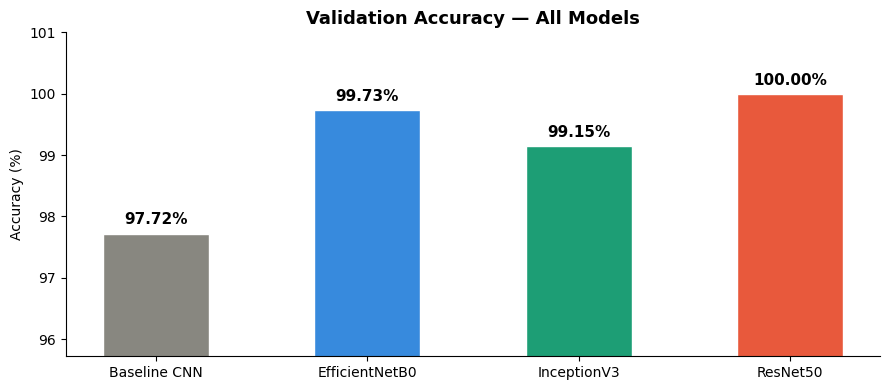

💾 Saved → results/phase4_model_comparison.png


In [18]:
# Baseline result from Phase 3 — hardcode for comparison
baseline_acc = 0.9772

results = {
    "Baseline CNN"  : baseline_acc,
    "EfficientNetB0": acc_eff,
    "InceptionV3"   : acc_inc,
    "ResNet50"      : acc_res,
}

print("─" * 52)
print("  Phase 4 Summary — Validation Accuracy")
print("─" * 52)
for name, acc in results.items():
    delta = acc - baseline_acc
    marker = "← baseline" if name == "Baseline CNN" else f"({'+' if delta >= 0 else ''}{delta*100:.2f}% vs baseline)"
    print(f"  {name:20s}: {acc*100:.2f}%  {marker}")
print("─" * 52)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#888780", "#378ADD", "#1D9E75", "#E8593C"]
bars   = ax.bar(results.keys(), [v * 100 for v in results.values()],
                color=colors, width=0.5, edgecolor="white")

for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f"{val*100:.2f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Validation Accuracy — All Models", fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(min(results.values()) * 100 - 2, 101)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/phase4_model_comparison.png", dpi=150)
plt.show()
print("💾 Saved → results/phase4_model_comparison.png")

## What Comes Next — Phase 5: Evaluation

In Phase 5 we run the final, definitive evaluation of all four models
using the **test set** — data that no model has ever seen during training
or validation.

For each model we will compute:
- Accuracy, Precision, Recall, F1-score
- Confusion matrix
- ROC curve and AUC score
- Full classification report

All results are saved to `results/` for inclusion in the final report.